In [21]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use('ggplot')
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import os
os.environ["OMP_NUM_THREADS"] = "1"

In [22]:
from src.config import FILE_BEVERAGE, ENCODINGS, FILE_ASSESS


In [23]:
os.chdir(r"C:\Users\print\OneDrive\Рабочий стол\Data_Analysis_in_Python\claster_analisis\data")

In [24]:
df = pd.read_csv(FILE_BEVERAGE, encoding=ENCODINGS[0], sep=';', index_col='numb.obs')

In [25]:
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [26]:
from sklearn.cluster import KMeans

In [27]:
max_iter_1 = 300 # задаем максимальное количество кол-во итераций

In [28]:
model = KMeans(n_clusters=3, max_iter=max_iter_1, random_state=42, n_init=10, verbose=0, tol=0.0001)


In [29]:
model.fit(df)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [30]:
model.n_iter_

4

In [31]:
max_iter_2 = 2

In [32]:
model_tmp = KMeans(n_clusters=3, random_state=42, max_iter=max_iter_2, verbose=0 )
model_tmp.fit(df)

KMeans(max_iter=2, n_clusters=3, random_state=42)

In [33]:
model_tmp.n_iter_

2

In [34]:
model.labels_

array([2, 1, 1, 0, 1, 2, 0, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 2, 2, 0, 1, 0, 1, 0])

In [35]:
model.cluster_centers_

array([[ 1.11022302e-16,  1.00000000e+00,  5.45454545e-01,
         5.45454545e-01, -5.55111512e-17, -5.55111512e-17,
         9.09090909e-01,  0.00000000e+00],
       [ 1.00000000e+00,  2.50000000e-01,  8.33333333e-02,
         0.00000000e+00,  9.16666667e-01, -5.55111512e-17,
        -5.55111512e-17,  3.33333333e-01],
       [ 7.27272727e-01,  2.72727273e-01,  9.09090909e-02,
         9.09090909e-02,  4.54545455e-01,  1.00000000e+00,
         9.09090909e-02,  4.54545455e-01]])

In [36]:
df['cluster'] = model.labels_
df.groupby('cluster').mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
0,0.000000,1.000000,0.545455,0.545455,0.000000,0.0,0.909091,0.000000
1,1.000000,0.250000,0.083333,0.000000,0.916667,0.0,0.000000,0.333333
2,0.727273,0.272727,0.090909,0.090909,0.454545,1.0,0.090909,0.454545


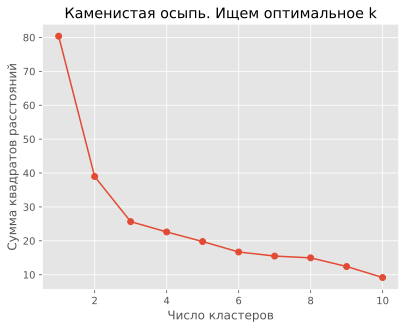

In [37]:
K = range(1, 11)

# Вычисляем значения критерия качества для разного числа кластеров
models = [KMeans(n_clusters=k, random_state=42).fit(df) for k in K]
dist = [model.inertia_ for model in models] # inertia - Ws

# Строим график каменистая осыпь
plt.plot(K, dist, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Каменистая осыпь. Ищем оптимальное k')
plt.show()

In [38]:
new_items = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0]
]
model.predict(new_items)

C:\Users\print\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2, 1])

In [39]:
df.groupby('cluster').size()

cluster
0    11
1    12
2    11
dtype: int64